# Aula 05 — Modelagem Preditiva: Classificação

**Disciplina:** Ciência de Dados  
**Plano de Ensino:** 5.1 — Aprendizado Supervisionado: Classificação  
**Data:** 05/10/2025

> Até aqui aprendemos a **coletar, limpar, transformar e explorar** dados. Agora damos o passo seguinte: **ensinar o computador a prever**. Nesta aula o alvo é uma **categoria** (espécie de flor, vinho bom ou não, sobreviveu ou não) — isso é **classificação**.

## Objetivos de aprendizagem

Ao final desta aula você será capaz de:

1. **Diferenciar** aprendizado supervisionado, classificação e regressão.
2. **Treinar e comparar** k-NN, Árvore de Decisão e Regressão Logística com `scikit-learn`.
3. **Separar** os dados em treino e teste corretamente (estratificação, sem vazamento).
4. **Avaliar** modelos com matriz de confusão, acurácia, precisão, recall, F1 e ROC-AUC — e escolher a métrica certa para cada problema.
5. **Reconhecer** *overfitting* e *underfitting* e usar **validação cruzada** para escolher hiperparâmetros.

---

## O que é aprendizado supervisionado?

É aprender uma função $f: X \rightarrow y$ a partir de **exemplos rotulados**. Chama-se *supervisionado* porque cada exemplo de treino vem com a **resposta certa** (o rótulo) — como um professor corrigindo exercícios até o aluno aprender o padrão.

| | **Classificação** (hoje) | **Regressão** (Aula 11) |
|---|---|---|
| Alvo $y$ | uma **categoria** | um **número contínuo** |
| Exemplos | spam/não spam, espécie, fraude, vinho bom/ruim | preço de casa, gorjeta, temperatura |
| Saída do modelo | classe (e a probabilidade de cada classe) | valor numérico |
| Métricas | acurácia, precisão, recall, F1, AUC | MAE, RMSE, R² |

**Vocabulário essencial:**

| Termo | Significado |
|---|---|
| **Features** ($X$) | variáveis de entrada — as colunas usadas para prever |
| **Alvo / rótulo** ($y$) | o que queremos prever |
| **Treino** | dados que o modelo usa para aprender |
| **Teste** | dados "escondidos", usados só para medir o desempenho em dados novos |
| **`fit` / `predict`** | aprender com os dados / fazer previsões |
| **Hiperparâmetro** | configuração escolhida **por nós** antes do treino (ex.: número de vizinhos) |
| **Generalização** | acertar em dados que o modelo **nunca viu** — o objetivo real |

**O fluxo é sempre o mesmo no scikit-learn:**

```
1. Separar X e y
2. Dividir em treino e teste
3. Escolher o modelo   →  modelo = Algoritmo(hiperparâmetros)
4. Treinar             →  modelo.fit(X_train, y_train)
5. Prever              →  y_pred = modelo.predict(X_test)
6. Avaliar             →  métrica(y_test, y_pred)
```

> **Dica:** a API é idêntica para todos os modelos. Aprendeu a usar um, aprendeu a usar todos — o que muda é *quando* usar cada um.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid', palette='tab10')

# Iris: 150 flores, 4 medidas em cm e 3 espécies — o "hello world" da classificação
iris = load_iris(as_frame=True)
df_iris = iris.frame.copy()
df_iris['especie'] = df_iris['target'].map(dict(enumerate(iris.target_names)))

print('Shape:', df_iris.shape)
print('Features:', iris.feature_names)
print('\nQuantidade por espécie:')
print(df_iris['especie'].value_counts())
df_iris.head()

Shape: (150, 6)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Quantidade por espécie:
setosa        50
versicolor    50
virginica     50
Name: especie, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,especie
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 1. Primeiro passo: separar treino e teste

Se avaliarmos o modelo nos **mesmos dados** em que ele treinou, é como aplicar uma prova com as questões que o aluno já decorou: medimos **memorização**, não **aprendizado**. Por isso separamos uma parte dos dados que o modelo nunca vê durante o treino.

| Parâmetro de `train_test_split` | O que faz |
|---|---|
| `test_size=0.3` | reserva 30% para teste (20–30% é o usual) |
| `random_state=42` | fixa a "semente" do sorteio → resultado reprodutível |
| `stratify=y` | mantém a **mesma proporção de classes** no treino e no teste (essencial em dados desbalanceados) |

> **Regra de ouro:** o conjunto de teste só é usado **no final**. Nada de ajustar escalonador, escolher features ou hiperparâmetros olhando para ele — isso é *data leakage* (Aula 06).

In [2]:
X = df_iris[iris.feature_names]
y = df_iris['especie']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print('\nProporção de classes (treino vs. teste) — iguais graças ao stratify:')
print(pd.DataFrame({
    'treino': y_train.value_counts(normalize=True).round(3),
    'teste': y_test.value_counts(normalize=True).round(3),
}))

Treino: 105 amostras | Teste: 45 amostras

Proporção de classes (treino vs. teste) — iguais graças ao stratify:
            treino  teste
setosa       0.333  0.333
versicolor   0.333  0.333
virginica    0.333  0.333


## 2. Três algoritmos clássicos de classificação

| Algoritmo | Intuição | Hiperparâmetro principal | Precisa escalonar? | Pontos fortes | Limitações |
|---|---|---|---|---|---|
| **k-NN** (*k-Nearest Neighbors*) | "Diga-me com quem andas": olha os **k vizinhos mais próximos** e faz uma votação | `n_neighbors` (k) | **Sim** (usa distância) | simples, não assume forma nenhuma | lento em bases grandes; sensível à escala e a features irrelevantes |
| **Árvore de Decisão** | Sequência de **perguntas sim/não** (ex.: "pétala < 2,45 cm?") até chegar a uma folha | `max_depth` | Não | interpretável, captura relações não lineares | faz *overfitting* com facilidade; instável |
| **Regressão Logística** | Combinação linear das features passada por uma **sigmoide** → probabilidade | `C` (regularização) | Recomendado | rápida, dá probabilidades, coeficientes interpretáveis | fronteira de decisão **linear** |

> **Pegadinha clássica:** apesar do nome, a regressão logística é um modelo de **classificação**.

Abaixo treinamos os três. Repare no uso de `make_pipeline(StandardScaler(), ...)` para os modelos que dependem de escala: o escalonador aprende média e desvio **somente no treino**, exatamente como vimos na Aula 06.

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

modelos = {
    'k-NN (k=5)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    'Árvore de Decisão': DecisionTreeClassifier(random_state=42),
    'Regressão Logística': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
}

resultados = []
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)                       # 1) aprende com o treino
    resultados.append({
        'modelo': nome,
        'acurácia treino': accuracy_score(y_train, modelo.predict(X_train)),
        'acurácia teste': accuracy_score(y_test, modelo.predict(X_test)),   # 2) avalia em dados novos
    })

pd.DataFrame(resultados).set_index('modelo').round(3)

,acurácia treino,acurácia teste
modelo,,
k-NN (k=5),0.981,0.911
Árvore de Decisão,1.000,0.933
Regressão Logística,0.981,0.911


**Como ler:** o Iris é um problema fácil — os três modelos acertam mais de 90% no teste. Repare na árvore: **100% no treino**. Uma árvore sem limite de profundidade cresce até classificar perfeitamente cada exemplo de treino — um primeiro sinal de **memorização** (*overfitting*), que vamos estudar na seção 6.

### 2.1 Fronteiras de decisão: como cada modelo "pensa"

Para conseguir desenhar, usamos só **duas features** (as medidas da pétala, que mais separam as espécies). Cada região colorida é a classe que o modelo preveria para uma flor com aquelas medidas; os pontos são as flores do **teste**.

- **k-NN:** fronteiras com bordas serrilhadas, definidas pelos vizinhos de cada região.
- **Árvore:** fronteiras em "degraus" — cortes retos, paralelos aos eixos (cada corte é uma pergunta).
- **Regressão Logística:** fronteiras **retas** (modelo linear).

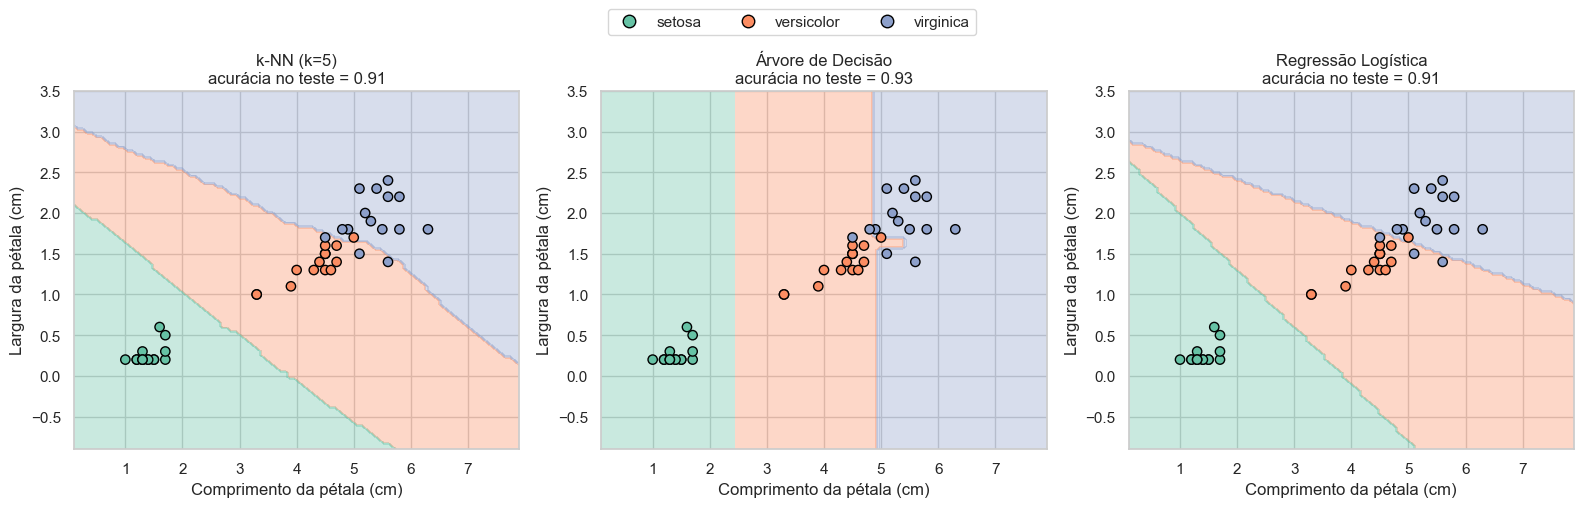

In [4]:
from sklearn.base import clone
from sklearn.inspection import DecisionBoundaryDisplay
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

feats_2d = ['petal length (cm)', 'petal width (cm)']
codigo = {nome: i for i, nome in enumerate(iris.target_names)}   # setosa→0, versicolor→1, virginica→2
y_train_num, y_test_num = y_train.map(codigo), y_test.map(codigo)
cmap = ListedColormap(['#66c2a5', '#fc8d62', '#8da0cb'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (nome, modelo) in zip(axes, modelos.items()):
    modelo_2d = clone(modelo).fit(X_train[feats_2d], y_train_num)   # clone = mesma configuração, ainda não treinado
    DecisionBoundaryDisplay.from_estimator(
        modelo_2d, X_train[feats_2d], response_method='predict',
        cmap=cmap, alpha=0.35, ax=ax,
    )
    ax.scatter(X_test[feats_2d[0]], X_test[feats_2d[1]], c=y_test_num, cmap=cmap,
               edgecolors='black', s=45)
    acc = accuracy_score(y_test_num, modelo_2d.predict(X_test[feats_2d]))
    ax.set_title(f'{nome}\nacurácia no teste = {acc:.2f}')
    ax.set_xlabel('Comprimento da pétala (cm)')
    ax.set_ylabel('Largura da pétala (cm)')

legenda = [Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(i),
                  markeredgecolor='black', markersize=9, label=nome) for nome, i in codigo.items()]
fig.legend(handles=legenda, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.07))
plt.tight_layout()
plt.show()

### 2.2 Árvore de Decisão: um modelo que dá para ler

A grande vantagem da árvore é a **interpretabilidade**: o modelo é literalmente um fluxograma de perguntas. Limitamos a profundidade a 3 para caber na tela.

**Como ler cada nó:**

- **Primeira linha:** a pergunta (ex.: `petal length (cm) <= 2.45`). Se *verdadeiro*, siga para a esquerda; se *falso*, para a direita.
- **`gini`:** impureza do nó. **0** = todas as amostras são da mesma classe (nó "puro"); quanto maior, mais misturado.
- **`samples`:** quantas amostras de treino chegaram ao nó.
- **`value`:** quantas amostras de cada classe estão no nó.
- **`class`:** a classe majoritária — é o que a árvore prevê se parar ali.

A árvore escolhe, a cada passo, a pergunta que **mais reduz a impureza**.

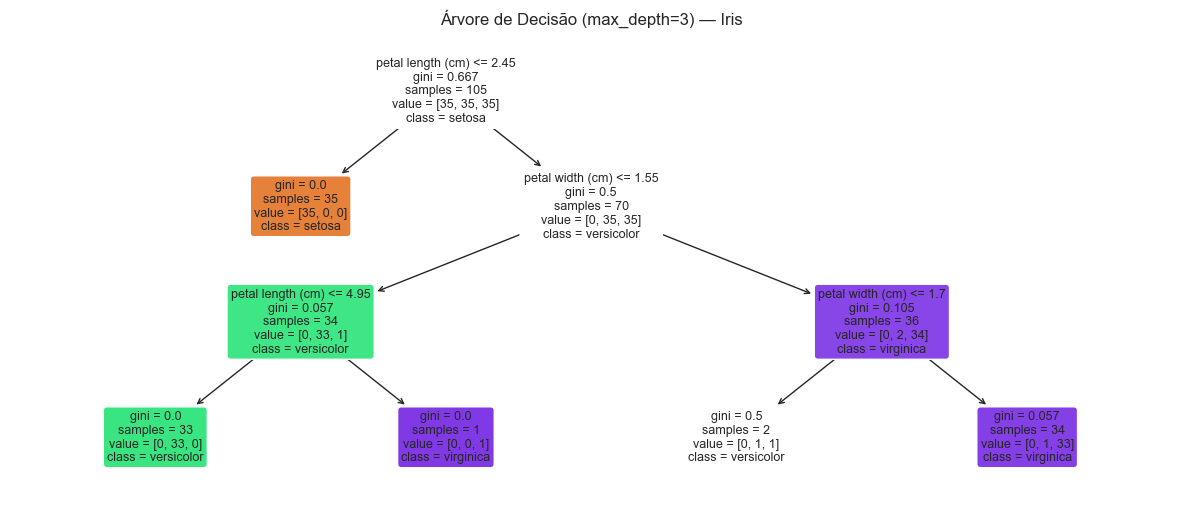

Acurácia no teste com apenas 3 níveis: 0.978

As mesmas regras em formato de texto:

|--- petal length (cm) <= 2.45
|   |--- class: setosa
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: versicolor
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: virginica
|   |--- petal width (cm) >  1.55
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- class: versicolor
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- class: virginica



In [5]:
from sklearn.tree import plot_tree, export_text

arvore = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(15, 6))
plot_tree(arvore, feature_names=list(X.columns), class_names=list(arvore.classes_),
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title('Árvore de Decisão (max_depth=3) — Iris')
plt.show()

print(f'Acurácia no teste com apenas 3 níveis: {accuracy_score(y_test, arvore.predict(X_test)):.3f}')
print('\nAs mesmas regras em formato de texto:\n')
print(export_text(arvore, feature_names=list(X.columns)))

### 2.3 Regressão Logística: da reta à probabilidade

A regressão logística calcula uma **combinação linear** das features

$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p$$

e passa o resultado pela **função sigmoide**, que "espreme" qualquer número no intervalo $[0, 1]$:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

O resultado é interpretado como a **probabilidade** de pertencer à classe positiva. Por padrão, se a probabilidade for $\geq 0{,}5$, o modelo prevê a classe positiva. Com mais de duas classes (como no Iris), o modelo calcula uma probabilidade para cada classe e escolhe a maior.

> Ter **probabilidades** (e não só a classe) é muito útil: permite dizer "tenho 95% de certeza" vs. "estou em dúvida" — e ajustar o limiar de decisão (seção 4).

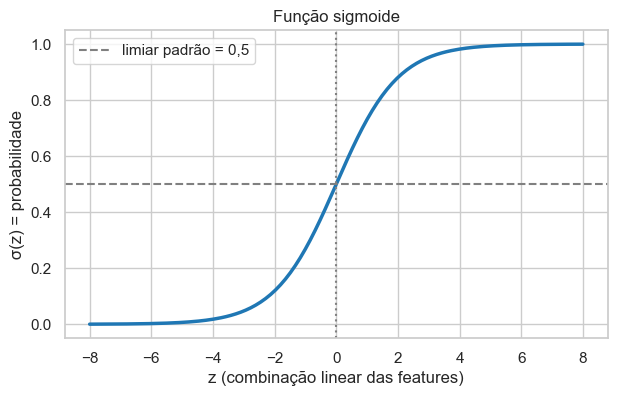

,setosa,versicolor,virginica,previsto,real
107,0.000,0.102,0.898,virginica,virginica
63,0.014,0.790,0.196,versicolor,versicolor
133,0.004,0.621,0.376,versicolor,virginica
56,0.022,0.629,0.349,versicolor,versicolor
127,0.005,0.385,0.610,virginica,virginica
140,0.000,0.022,0.978,virginica,virginica


In [6]:
z = np.linspace(-8, 8, 200)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z, 1 / (1 + np.exp(-z)), linewidth=2.5)
ax.axhline(0.5, color='gray', linestyle='--', label='limiar padrão = 0,5')
ax.axvline(0, color='gray', linestyle=':')
ax.set_xlabel('z (combinação linear das features)')
ax.set_ylabel('σ(z) = probabilidade')
ax.set_title('Função sigmoide')
ax.legend()
plt.show()

# Probabilidades previstas para 6 flores do teste
logreg = modelos['Regressão Logística']
amostra = X_test.head(6)
proba = pd.DataFrame(logreg.predict_proba(amostra), columns=logreg.classes_, index=amostra.index).round(3)
proba['previsto'] = logreg.predict(amostra)
proba['real'] = y_test.loc[amostra.index]
proba

**Como ler a tabela:** cada linha soma 1. A classe prevista é a de maior probabilidade. Linhas com probabilidades mais "divididas" (ex.: 0,7 × 0,3) são as flores em que o modelo está **menos confiante** — normalmente as que ficam perto da fronteira entre *versicolor* e *virginica*.

---

## 3. Avaliando classificadores: além da acurácia

O Iris é balanceado e fácil. Problemas reais raramente são assim. Vamos voltar ao **Wine Quality** (Aulas 06 e 09) com um alvo binário:

- `bom = 1` se `quality >= 7`, senão `bom = 0`.

Só cerca de **14%** dos vinhos são "bons" → o problema é **desbalanceado**, e isso muda completamente a forma de avaliar.

> A célula abaixo procura o CSV na pasta `dados/` (também na da Aula 04). Se não encontrar, baixa uma vez da UCI.

In [7]:
from pathlib import Path
import urllib.request

def achar_wine():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for cand in [base / 'dados' / 'winequality-red.csv',
                     base / 'aula-04' / 'dados' / 'winequality-red.csv']:
            if cand.exists():
                return cand
    destino = Path.cwd() / 'dados' / 'winequality-red.csv'
    destino.parent.mkdir(parents=True, exist_ok=True)
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
    print('Arquivo local ausente — baixando de', url)
    urllib.request.urlretrieve(url, destino)
    return destino

wine = pd.read_csv(achar_wine(), sep=';')            # o CSV da UCI usa ';'
wine['bom'] = (wine['quality'] >= 7).astype(int)     # 1 = vinho bom (nota >= 7)

print('Shape:', wine.shape)
print('\nDistribuição do alvo:')
print(wine['bom'].value_counts().rename({0: 'não bom (0)', 1: 'bom (1)'}))
print(f"\nProporção de vinhos bons: {wine['bom'].mean():.1%}")

# ATENÇÃO: 'quality' precisa sair de X — ela É a resposta (vazamento de alvo)
X_w = wine.drop(columns=['quality', 'bom'])
y_w = wine['bom']

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_w, y_w, test_size=0.25, random_state=42, stratify=y_w
)
print(f'\nTreino: {len(Xw_train)} | Teste: {len(Xw_test)} | Features: {X_w.shape[1]}')

Shape: (1599, 13)

Distribuição do alvo:
não bom (0)    1382
bom (1)         217
Name: bom, dtype: int64

Proporção de vinhos bons: 13.6%

Treino: 1199 | Teste: 400 | Features: 11


### 3.1 A linha de base (*baseline*): o modelo "preguiçoso"

Antes de comemorar qualquer resultado, compare com o modelo mais burro possível. O `DummyClassifier(strategy='most_frequent')` **ignora as features** e sempre responde a classe mais comum ("não bom").

Se o seu modelo não supera o *baseline*, ele não aprendeu nada útil.

In [8]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent').fit(Xw_train, yw_train)
y_dummy = dummy.predict(Xw_test)

print(f'Acurácia do modelo preguiçoso: {accuracy_score(yw_test, y_dummy):.1%}')
encontrados = int(((y_dummy == 1) & (yw_test == 1)).sum())
print(f'Vinhos bons que ele encontrou: {encontrados} de {int(yw_test.sum())}')

Acurácia do modelo preguiçoso: 86.5%
Vinhos bons que ele encontrou: 0 de 54


**O paradoxo da acurácia:** um modelo que **nunca** encontra um vinho bom tem quase **87% de acurácia**! Em dados desbalanceados, a acurácia sozinha engana. Precisamos olhar **que tipo de erro** o modelo comete.

### 3.2 Matriz de confusão e métricas derivadas

A matriz de confusão cruza o **real** com o **previsto**:

```
                      Previsto: 0 (não bom)     Previsto: 1 (bom)
Real: 0 (não bom)     VN  verdadeiro negativo   FP  falso positivo (alarme falso)
Real: 1 (bom)         FN  falso negativo (perdeu)  VP  verdadeiro positivo
```

| Métrica | Fórmula | Pergunta que responde | Quando priorizar |
|---|---|---|---|
| **Acurácia** | $\frac{VP + VN}{\text{total}}$ | Quanto acertei no geral? | classes balanceadas |
| **Precisão** | $\frac{VP}{VP + FP}$ | Dos que eu disse "bom", quantos eram mesmo? | quando o **falso positivo** é caro (ex.: filtro de spam apagando e-mail importante) |
| **Recall** (sensibilidade) | $\frac{VP}{VP + FN}$ | Dos bons de verdade, quantos eu encontrei? | quando o **falso negativo** é caro (ex.: diagnóstico de câncer, fraude) |
| **F1-score** | $2 \cdot \frac{P \cdot R}{P + R}$ | Qual o equilíbrio entre precisão e recall? | dados desbalanceados, quando os dois erros importam |

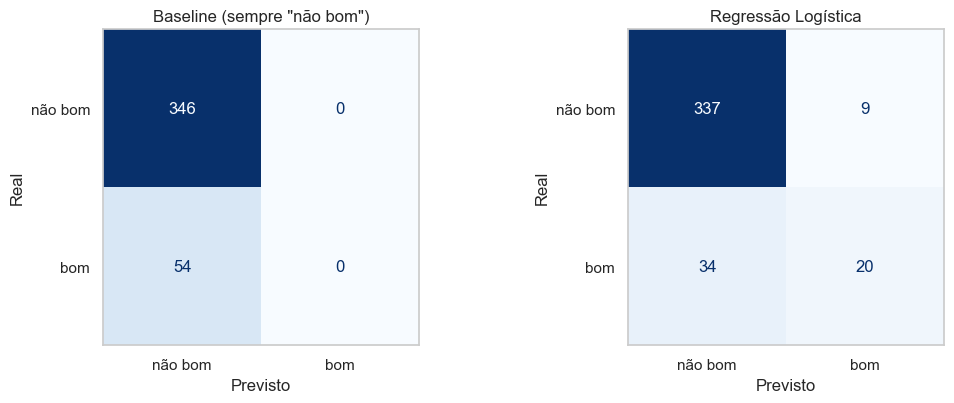

Relatório de classificação — Regressão Logística
              precision    recall  f1-score   support

     não bom      0.908     0.974     0.940       346
         bom      0.690     0.370     0.482        54

    accuracy                          0.892       400
   macro avg      0.799     0.672     0.711       400
weighted avg      0.879     0.892     0.878       400



In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

logreg_w = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logreg_w.fit(Xw_train, yw_train)
y_pred_lr = logreg_w.predict(Xw_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (nome, y_pred) in zip(axes, [('Baseline (sempre "não bom")', y_dummy),
                                      ('Regressão Logística', y_pred_lr)]):
    ConfusionMatrixDisplay.from_predictions(yw_test, y_pred, display_labels=['não bom', 'bom'],
                                            cmap='Blues', colorbar=False, ax=ax)
    ax.set_title(nome)
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')
    ax.grid(False)
plt.tight_layout()
plt.show()

print('Relatório de classificação — Regressão Logística')
print(classification_report(yw_test, y_pred_lr, target_names=['não bom', 'bom'], digits=3))

**Como ler o `classification_report`:**

- Cada linha traz precisão, recall e F1 **daquela classe** tratada como positiva. O que nos interessa é a linha **"bom"**.
- **`support`:** quantas amostras reais de cada classe existem no teste.
- **`macro avg`:** média simples entre as classes (trata as duas como igualmente importantes).
- **`weighted avg`:** média ponderada pelo `support` (dominada pela classe majoritária).

A regressão logística tem acurácia parecida com a do *baseline*, mas agora **encontra parte dos vinhos bons** — o recall da classe "bom" saiu de 0. Ainda assim, deixa passar muitos deles (falsos negativos).

### 3.3 Comparando vários modelos com as métricas certas

Incluímos dois modelos novos:

- **Regressão Logística com `class_weight='balanced'`:** errar um exemplo da classe rara "custa" mais no treino, forçando o modelo a prestar atenção nela.
- **Random Forest:** um conjunto de muitas árvores treinadas em amostras diferentes dos dados, que **votam** na resposta final. Costuma ser bem mais estável e preciso que uma árvore sozinha (veremos com mais detalhes na Aula 11).

> Aqui usamos o teste para comparar modelos por fins **didáticos**. Na seção 5 faremos essa escolha do jeito correto, com validação cruzada.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

def avaliar(nome, modelo):
    modelo.fit(Xw_train, yw_train)
    y_pred = modelo.predict(Xw_test)
    return {
        'modelo': nome,
        'acurácia': accuracy_score(yw_test, y_pred),
        'precisão': precision_score(yw_test, y_pred, zero_division=0),
        'recall': recall_score(yw_test, y_pred),
        'F1': f1_score(yw_test, y_pred, zero_division=0),
    }

modelos_w = {
    'Baseline (mais frequente)': DummyClassifier(strategy='most_frequent'),
    'k-NN (k=5)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    'Árvore (max_depth=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Regressão Logística': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    'Reg. Logística (balanced)': make_pipeline(StandardScaler(),
                                               LogisticRegression(max_iter=1000, class_weight='balanced')),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

tabela = pd.DataFrame([avaliar(nome, m) for nome, m in modelos_w.items()]).set_index('modelo')
tabela.round(3)

,acurácia,precisão,recall,F1
modelo,,,,
Baseline (mais frequente),0.865,0.000,0.000,0.000
k-NN (k=5),0.892,0.667,0.407,0.506
Árvore (max_depth=5),0.905,0.722,0.481,0.578
Regressão Logística,0.892,0.690,0.370,0.482
Reg. Logística (balanced),0.790,0.368,0.778,0.500
Random Forest,0.940,0.875,0.648,0.745


**O que observar:**

- A **acurácia** quase não diferencia os modelos (todos perto do *baseline*). Precisão, recall e F1 diferenciam — e muito.
- **`class_weight='balanced'`** troca precisão por recall: o modelo passa a encontrar a grande maioria dos vinhos bons, mas dá mais alarmes falsos.
- Neste split de teste, o **Random Forest** teve o melhor equilíbrio (maior F1). Guarde esse número: na seção 5 vamos ver se ele se sustenta.

**Não existe "melhor modelo" no abstrato** — depende do custo de cada erro. Se o produtor quer separar um lote *premium* e não pode errar, prioriza **precisão**. Se quer achar todos os candidatos para uma segunda análise, prioriza **recall**.

---

## 4. Limiar de decisão e curva ROC

Modelos como a regressão logística retornam uma **probabilidade** (`predict_proba`). O `predict` simplesmente aplica o limiar padrão de **0,5**. Mas esse limiar é uma escolha nossa:

- **Baixar o limiar** → mais vinhos classificados como "bom" → **recall ↑, precisão ↓**
- **Subir o limiar** → só os casos de alta confiança → **precisão ↑, recall ↓**

A **curva ROC** mostra esse compromisso para **todos os limiares** de uma vez:

- Eixo X: **taxa de falsos positivos** (FPR) = $\frac{FP}{FP + VN}$
- Eixo Y: **taxa de verdadeiros positivos** (TPR = recall)
- **AUC** (área sob a curva): **0,5** = chute aleatório; **1,0** = separação perfeita. Interpretação: a probabilidade de o modelo dar uma nota maior a um vinho bom sorteado do que a um vinho ruim sorteado.

> A AUC avalia o modelo **independentemente do limiar** — útil para comparar modelos antes de decidir onde cortar.

In [11]:
proba_bom = logreg_w.predict_proba(Xw_test)[:, 1]   # coluna 1 = probabilidade de ser "bom"

linhas = []
for limiar in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = (proba_bom >= limiar).astype(int)
    linhas.append({
        'limiar': limiar,
        'previstos como bom': int(y_pred.sum()),
        'precisão': precision_score(yw_test, y_pred, zero_division=0),
        'recall': recall_score(yw_test, y_pred),
        'F1': f1_score(yw_test, y_pred, zero_division=0),
    })
print('Efeito do limiar na Regressão Logística:')
pd.DataFrame(linhas).set_index('limiar').round(3)

Efeito do limiar na Regressão Logística:


,previstos como bom,precisão,recall,F1
limiar,,,,
0.1,132,0.333,0.815,0.473
0.2,88,0.443,0.722,0.549
0.3,64,0.484,0.574,0.525
0.4,42,0.571,0.444,0.500
0.5,29,0.690,0.370,0.482
0.6,17,0.765,0.241,0.366
0.7,7,0.571,0.074,0.131


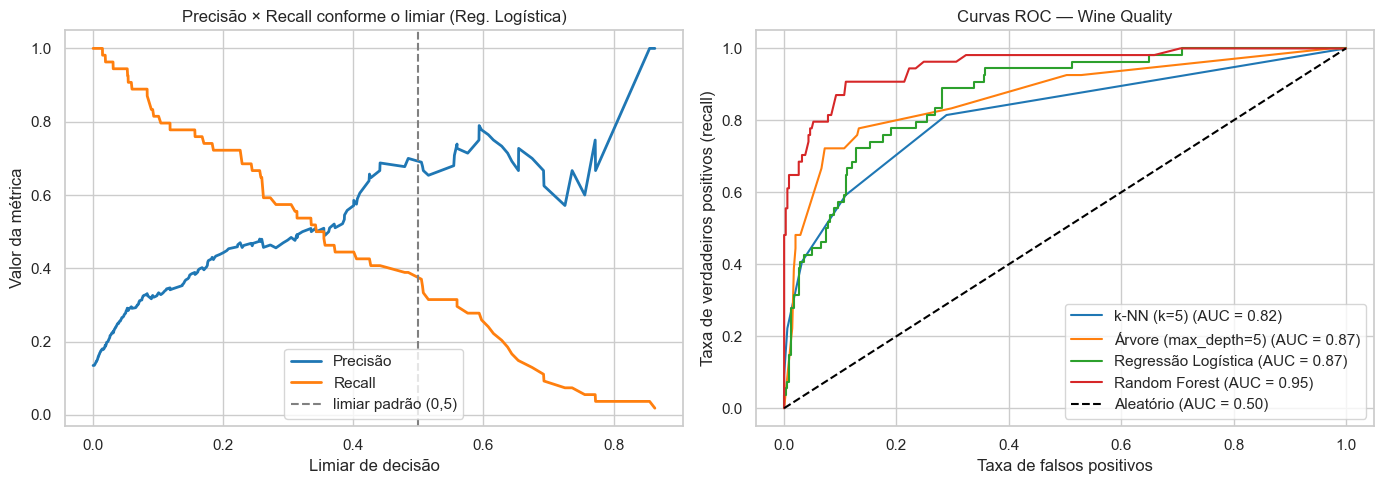

In [12]:
from sklearn.metrics import precision_recall_curve, RocCurveDisplay

prec, rec, limiares = precision_recall_curve(yw_test, proba_bom)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(limiares, prec[:-1], label='Precisão', linewidth=2)
axes[0].plot(limiares, rec[:-1], label='Recall', linewidth=2)
axes[0].axvline(0.5, color='gray', linestyle='--', label='limiar padrão (0,5)')
axes[0].set_xlabel('Limiar de decisão')
axes[0].set_ylabel('Valor da métrica')
axes[0].set_title('Precisão × Recall conforme o limiar (Reg. Logística)')
axes[0].legend()

for nome in ['k-NN (k=5)', 'Árvore (max_depth=5)', 'Regressão Logística', 'Random Forest']:
    RocCurveDisplay.from_estimator(modelos_w[nome], Xw_test, yw_test, name=nome, ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.50)')
axes[1].set_xlabel('Taxa de falsos positivos')
axes[1].set_ylabel('Taxa de verdadeiros positivos (recall)')
axes[1].set_title('Curvas ROC — Wine Quality')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

**Como ler:**

- **Esquerda:** as curvas se cruzam — não dá para maximizar precisão e recall ao mesmo tempo. O limiar é uma **decisão de negócio**, não técnica.
- **Direita:** quanto mais a curva "abraça" o canto superior esquerdo, melhor. O Random Forest tem a maior AUC; o k-NN, a menor. A curva do k-NN é feita de poucos segmentos retos porque, com k=5, a "probabilidade" só pode valer 0, 0,2, 0,4, 0,6, 0,8 ou 1 (fração de vizinhos bons).

---

## 5. Validação cruzada: uma avaliação mais confiável

Um único `train_test_split` depende da **sorte do sorteio**: com outra semente, os números mudam. Além disso, se escolhermos o modelo olhando para o teste, ele deixa de ser um teste "limpo".

A **validação cruzada k-fold** resolve os dois problemas usando **apenas o treino**:

```
Fold 1: [VALID][treino][treino][treino][treino]
Fold 2: [treino][VALID][treino][treino][treino]
Fold 3: [treino][treino][VALID][treino][treino]
Fold 4: [treino][treino][treino][VALID][treino]
Fold 5: [treino][treino][treino][treino][VALID]
         → 5 notas → média ± desvio padrão
```

- Cada amostra de treino é usada para validar **exatamente uma vez**.
- O **desvio padrão** entre os folds mostra o quanto o resultado é estável.
- `StratifiedKFold` mantém a proporção de classes em cada fold (fundamental com desbalanceamento).

> **Fluxo profissional:** escolha modelo e hiperparâmetros com validação cruzada no **treino** → avalie o escolhido **uma única vez** no **teste**.

,acurácia,F1,ROC-AUC
modelo,,,
k-NN (k=5),0.865 ± 0.021,0.440 ± 0.037,0.806 ± 0.023
Árvore (max_depth=5),0.862 ± 0.018,0.429 ± 0.053,0.746 ± 0.067
Regressão Logística,0.873 ± 0.011,0.393 ± 0.095,0.871 ± 0.016
Reg. Logística (balanced),0.788 ± 0.043,0.514 ± 0.036,0.872 ± 0.014
Random Forest,0.887 ± 0.016,0.455 ± 0.100,0.886 ± 0.028


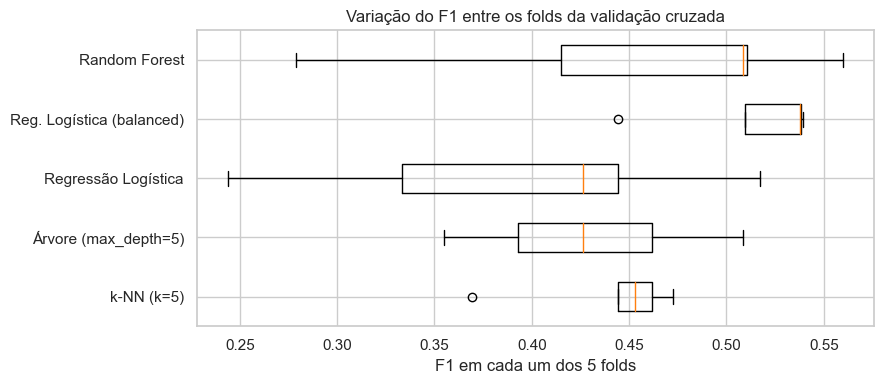

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

linhas, f1_por_fold = [], {}
for nome, modelo in modelos_w.items():
    if nome.startswith('Baseline'):
        continue
    res = cross_validate(modelo, Xw_train, yw_train, cv=cv, scoring=['accuracy', 'f1', 'roc_auc'])
    f1_por_fold[nome] = res['test_f1']
    linhas.append({
        'modelo': nome,
        'acurácia': f"{res['test_accuracy'].mean():.3f} ± {res['test_accuracy'].std():.3f}",
        'F1': f"{res['test_f1'].mean():.3f} ± {res['test_f1'].std():.3f}",
        'ROC-AUC': f"{res['test_roc_auc'].mean():.3f} ± {res['test_roc_auc'].std():.3f}",
    })

display(pd.DataFrame(linhas).set_index('modelo'))

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(list(f1_por_fold.values()), vert=False, labels=list(f1_por_fold.keys()))
ax.set_xlabel('F1 em cada um dos 5 folds')
ax.set_title('Variação do F1 entre os folds da validação cruzada')
plt.tight_layout()
plt.show()

**Como ler:** o valor após o `±` mostra a variação entre os folds. Se dois modelos têm médias próximas e desvios grandes, **não dá para afirmar** que um é melhor que o outro. O boxplot deixa isso visível: caixas sobrepostas = diferença incerta.

**Compare com a seção 3.3:** no split de teste, o Random Forest teve F1 ≈ 0,75. Na validação cruzada, seu F1 médio é ≈ 0,46 — e varia muito entre os folds (de ~0,28 a ~0,56). Aquele split de teste foi "favorável". Já a Regressão Logística *balanced* tem o maior F1 médio e é a mais **estável**. É exatamente por isso que não se escolhe modelo olhando um único split de teste.

---

## 6. *Overfitting*, *underfitting* e ajuste de hiperparâmetros

Todo modelo tem uma "complexidade" controlada por hiperparâmetros. O objetivo é o ponto de equilíbrio:

| | **Underfitting** | **Bom ajuste** | **Overfitting** |
|---|---|---|---|
| Desempenho no treino | baixo | alto | altíssimo (quase perfeito) |
| Desempenho na validação | baixo | alto | **baixo** |
| O que aconteceu | modelo simples demais | capturou o padrão | **decorou o ruído** do treino |
| Analogia | aluno que não estudou | aluno que entendeu a matéria | aluno que decorou o gabarito |
| No k-NN | k muito grande | k intermediário | k = 1 |
| Na árvore | `max_depth` muito pequeno | intermediário | sem limite de profundidade |

A **curva de validação** (`validation_curve`) treina o modelo com vários valores do hiperparâmetro e mostra o desempenho no treino e na validação cruzada. O **vão** entre as curvas é o sinal de *overfitting*.

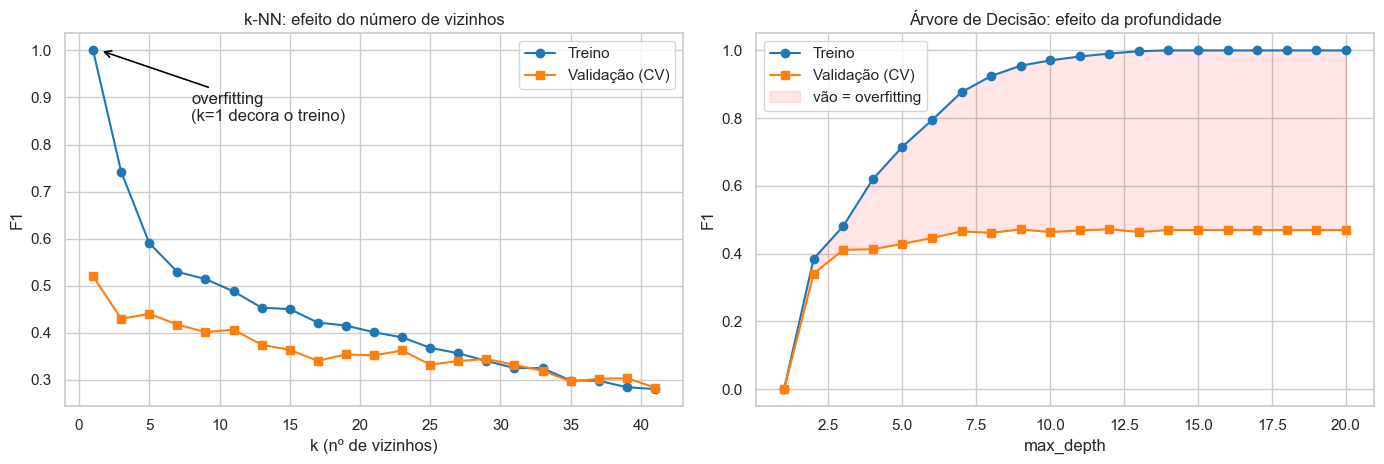

In [14]:
from sklearn.model_selection import validation_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# --- k-NN: k pequeno = complexo; k grande = simples ---
ks = list(range(1, 42, 2))
tr, va = validation_curve(
    make_pipeline(StandardScaler(), KNeighborsClassifier()), Xw_train, yw_train,
    param_name='kneighborsclassifier__n_neighbors', param_range=ks, cv=cv, scoring='f1',
)
axes[0].plot(ks, tr.mean(axis=1), 'o-', label='Treino')
axes[0].plot(ks, va.mean(axis=1), 's-', label='Validação (CV)')
axes[0].set_xlabel('k (nº de vizinhos)')
axes[0].set_ylabel('F1')
axes[0].set_title('k-NN: efeito do número de vizinhos')
axes[0].annotate('overfitting\n(k=1 decora o treino)', xy=(1.5, tr.mean(axis=1)[0]), xytext=(8, 0.85),
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
axes[0].legend()

# --- Árvore: profundidade pequena = simples; grande = complexa ---
profs = list(range(1, 21))
tr, va = validation_curve(
    DecisionTreeClassifier(random_state=42), Xw_train, yw_train,
    param_name='max_depth', param_range=profs, cv=cv, scoring='f1',
)
axes[1].plot(profs, tr.mean(axis=1), 'o-', label='Treino')
axes[1].plot(profs, va.mean(axis=1), 's-', label='Validação (CV)')
axes[1].fill_between(profs, va.mean(axis=1), tr.mean(axis=1), alpha=0.1, color='red',
                     label='vão = overfitting')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('F1')
axes[1].set_title('Árvore de Decisão: efeito da profundidade')
axes[1].legend()

plt.tight_layout()
plt.show()

**Como ler:**

- **k-NN:** com k=1 o F1 de treino é 1,0 (cada ponto é vizinho de si mesmo) — memorização pura. Conforme k cresce, treino e validação se aproximam — mas os dois caem: com k muito grande a maioria dos vizinhos é sempre "não bom", e o modelo prevê cada vez menos a classe rara (*underfitting*).
- **Árvore:** a curva de treino sobe sem parar com a profundidade; a de validação estabiliza bem abaixo. O vão crescente é o retrato do *overfitting*.

### 6.1 Busca automática de hiperparâmetros com `GridSearchCV`

Testar valores na mão é trabalhoso. O `GridSearchCV` testa **todas as combinações** de uma grade usando validação cruzada e guarda a melhor. Depois, avaliamos o modelo escolhido **uma única vez** no teste.

Melhores hiperparâmetros: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_leaf': 3}
F1 médio na validação cruzada: 0.547

Desempenho do modelo final no TESTE:
              precision    recall  f1-score   support

     não bom      0.954     0.954     0.954       346
         bom      0.704     0.704     0.704        54

    accuracy                          0.920       400
   macro avg      0.829     0.829     0.829       400
weighted avg      0.920     0.920     0.920       400



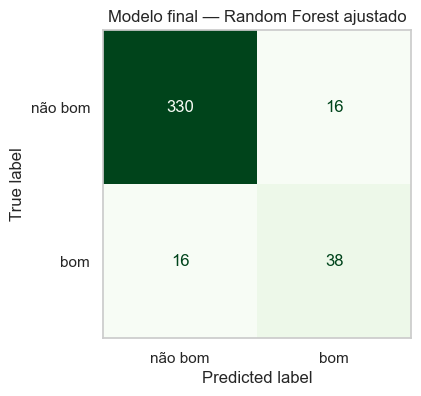

In [15]:
from sklearn.model_selection import GridSearchCV

grade = {
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 3],
    'class_weight': [None, 'balanced_subsample'],
}
busca = GridSearchCV(
    RandomForestClassifier(n_estimators=200, random_state=42),
    grade, cv=cv, scoring='f1', n_jobs=-1,
)
busca.fit(Xw_train, yw_train)

print('Melhores hiperparâmetros:', busca.best_params_)
print(f'F1 médio na validação cruzada: {busca.best_score_:.3f}')

# Avaliação final: a ÚNICA vez que o teste entra em cena
modelo_final = busca.best_estimator_
y_final = modelo_final.predict(Xw_test)
print('\nDesempenho do modelo final no TESTE:')
print(classification_report(yw_test, y_final, target_names=['não bom', 'bom'], digits=3))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(yw_test, y_final, display_labels=['não bom', 'bom'],
                                        cmap='Greens', colorbar=False, ax=ax)
ax.set_title('Modelo final — Random Forest ajustado')
ax.grid(False)
plt.show()

---

## 7. Resumo da aula

**Checklist de um projeto de classificação:**

1. **Defina o alvo e a métrica** de acordo com o custo de cada tipo de erro.
2. **Separe o teste primeiro** (`stratify=y`) e não toque nele até o fim.
3. Coloque todo o pré-processamento **dentro de um `Pipeline`** (sem vazamento).
4. **Compare com um *baseline*** (`DummyClassifier`).
5. Escolha modelo e hiperparâmetros com **validação cruzada** no treino.
6. Avalie o modelo escolhido **uma única vez** no teste.
7. **Interprete os erros:** matriz de confusão, limiar, quais casos o modelo erra.

**Qual métrica usar?**

| Situação | Métrica recomendada |
|---|---|
| Classes balanceadas, erros com custo parecido | Acurácia |
| Falso positivo é caro (spam, recomendação *premium*) | Precisão |
| Falso negativo é caro (doença, fraude, defeito) | Recall |
| Desbalanceado e os dois erros importam | F1 |
| Comparar modelos independentemente do limiar | ROC-AUC |

**Quando usar cada algoritmo (ponto de partida):**

| Algoritmo | Use quando… |
|---|---|
| Regressão Logística | quer um *baseline* forte, rápido e interpretável |
| Árvore de Decisão | precisa **explicar** as regras para pessoas não técnicas |
| k-NN | base pequena, poucas features, fronteiras irregulares |
| Random Forest | quer desempenho alto sem muito ajuste fino |

## Exercício — Quem sobreviveu ao Titanic?

Use o dataset **Titanic** (já vem no `seaborn`, nada para baixar) para prever a coluna `survived`. A célula abaixo já carrega os dados e faz a divisão treino/teste.

1. **Pré-processamento (Aula 06):** monte um `ColumnTransformer` com
   - numéricas (`age`, `fare`, `sibsp`, `parch`): `SimpleImputer(strategy='median')` + `StandardScaler`;
   - categóricas (`pclass`, `sex`, `embarked`): `SimpleImputer(strategy='most_frequent')` + `OneHotEncoder(handle_unknown='ignore')`.
2. **Baseline:** qual a acurácia do `DummyClassifier`? O dataset é balanceado?
3. **Compare** Regressão Logística, Árvore de Decisão e Random Forest (cada um num `Pipeline` com o pré-processamento) usando **validação cruzada** com acurácia, F1 e ROC-AUC.
4. **Curva de validação:** para a árvore, varie `max_depth` de 1 a 15. A partir de qual profundidade aparece *overfitting*?
5. **Modelo final:** escolha o melhor, avalie **uma vez** no teste e mostre a matriz de confusão. O modelo erra mais homens ou mulheres?
6. **Reflexão:** num cenário de resgate, você priorizaria precisão ou recall para a classe "sobreviveu"? Por quê? Como o limiar de decisão poderia ajudar?

In [16]:
# Ponto de partida — dados já carregados e divididos
titanic = sns.load_dataset('titanic')

features_num = ['age', 'fare', 'sibsp', 'parch']
features_cat = ['pclass', 'sex', 'embarked']

X_t = titanic[features_num + features_cat]
y_t = titanic['survived']

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_t, y_t, test_size=0.25, random_state=42, stratify=y_t
)
print(f'Treino: {Xt_train.shape} | Teste: {Xt_test.shape}')
print(f'Taxa de sobrevivência: {y_t.mean():.1%}')
print('\nValores ausentes no treino:')
print(Xt_train.isnull().sum())

Treino: (668, 7) | Teste: (223, 7)
Taxa de sobrevivência: 38.4%

Valores ausentes no treino:
age         131
fare          0
sibsp         0
parch         0
pclass        0
sex           0
embarked      2
dtype: int64


In [17]:
# Seu código a partir daqui:
# -----------------------------------------------

# 1. Pré-processamento
# from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder
#
# preproc = ColumnTransformer([
#     ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), features_num),
#     ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'),
#                           OneHotEncoder(handle_unknown='ignore')), features_cat),
# ])

# 2. Baseline
# DummyClassifier(strategy='most_frequent').fit(Xt_train, yt_train).score(Xt_test, yt_test)

# 3. Comparação com validação cruzada
# candidatos = {
#     'Reg. Logística': make_pipeline(preproc, LogisticRegression(max_iter=1000)),
#     'Árvore': make_pipeline(preproc, DecisionTreeClassifier(max_depth=4, random_state=42)),
#     'Random Forest': make_pipeline(preproc, RandomForestClassifier(n_estimators=200, random_state=42)),
# }
# for nome, modelo in candidatos.items():
#     res = cross_validate(modelo, Xt_train, yt_train, cv=cv, scoring=['accuracy', 'f1', 'roc_auc'])
#     ...

# 4. Curva de validação da árvore (param_name='decisiontreeclassifier__max_depth')

# 5. Modelo final + matriz de confusão
#    Dica para comparar por sexo: Xt_test['sex'] == 'male'

# 6. Reflexão (escreva em texto):